# Forcasting Time Serie

In [113]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from xgboost import XGBRegressor 
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [114]:
df = pd.read_csv(r"C:\Users\admin\Downloads\finance engeniering\data science\dataset\enerfy\PJME_hourly.csv")
df.head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


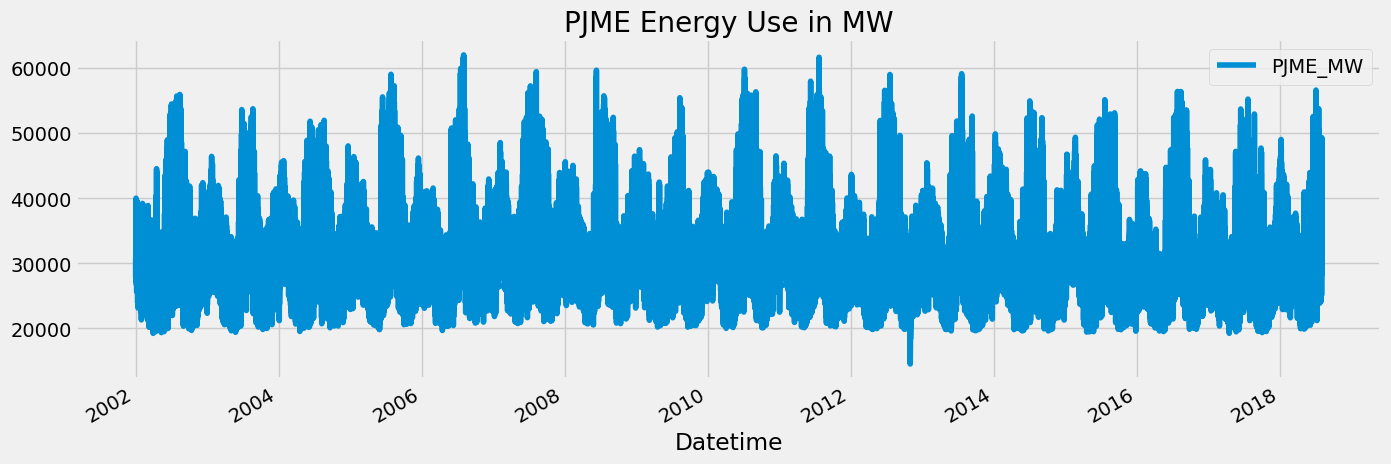

In [115]:
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df.plot(style='-',
        figsize=(15, 5),
        color=color_pal[0],
        title='PJME Energy Use in MW')
plt.show()

### Test / Train Split

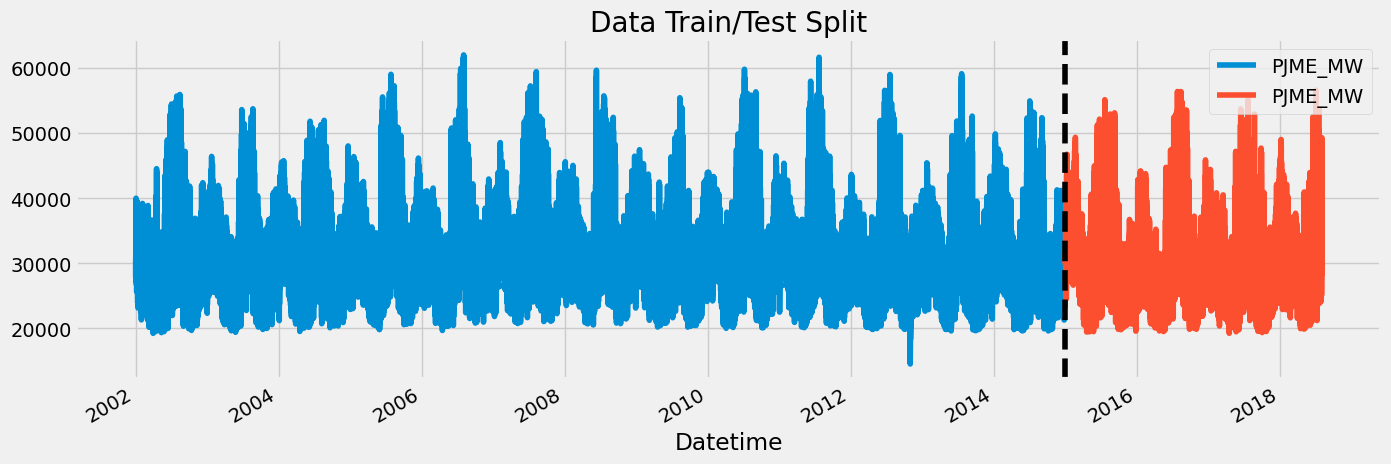

In [116]:
train = df.iloc[df.index < '2015-01-01']
test = df.iloc[df.index >= '2015-01-01']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('2015-01-01', color='black', ls='--')
ax.legend()
plt.show()

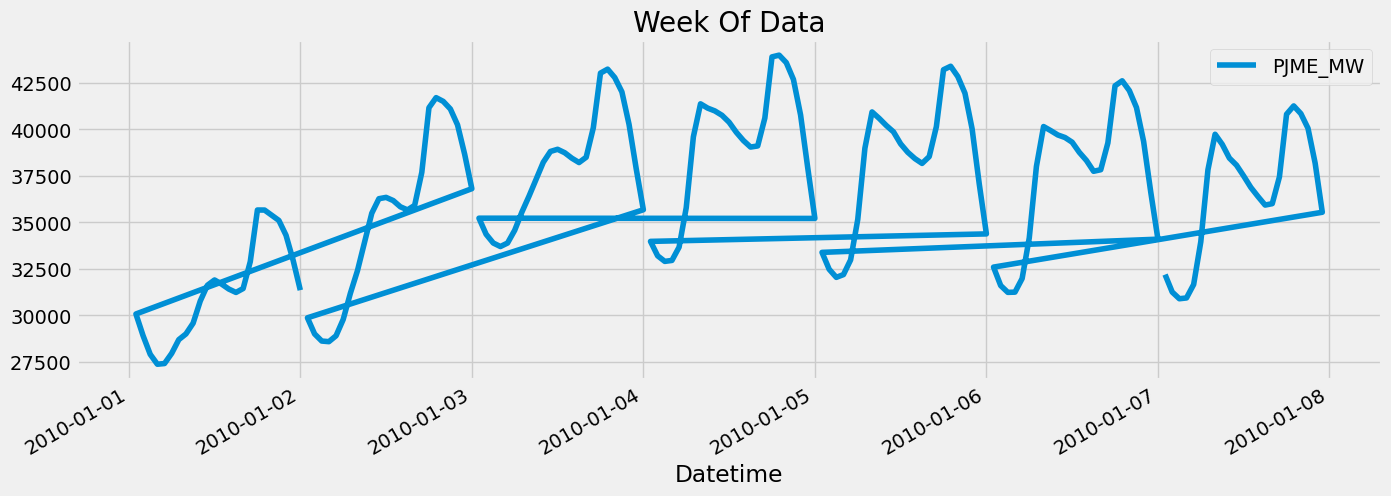

In [117]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

### Features Creation

In [118]:
def create_features(df):
    df = df.copy()
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['hour'] = df.index.hour
    return df
df = create_features(df)



### Visualization of Features

C:\Users\admin\AppData\Local\Temp\ipykernel_25392\2691390118.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='hour', y='PJME_MW',palette='winter')


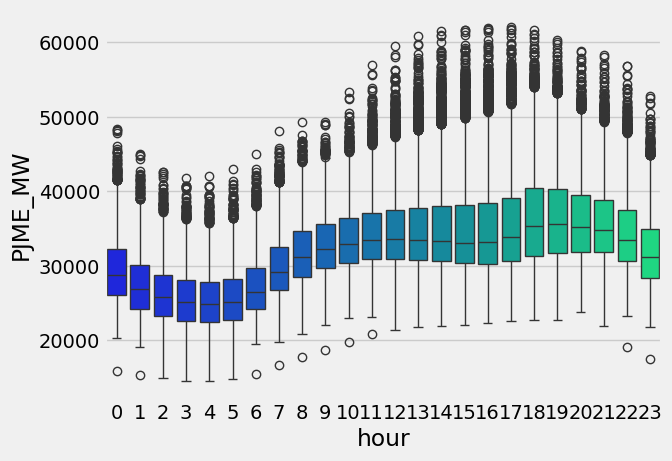

In [119]:
sns.boxplot(data=df, x='hour', y='PJME_MW',palette='winter')
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_25392\658283933.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW',palette='winter')


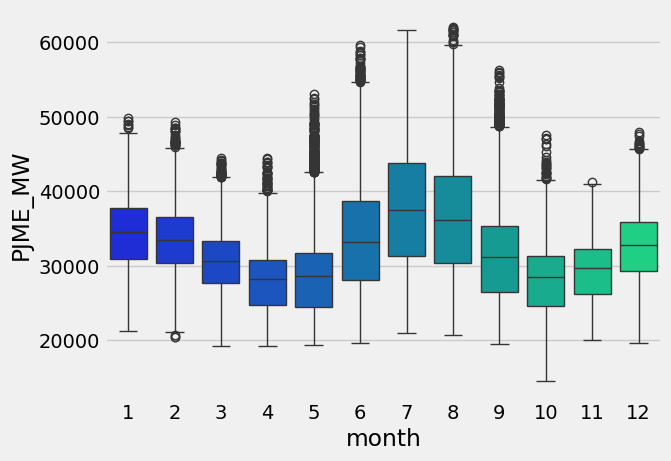

In [120]:
sns.boxplot(data=df, x='month', y='PJME_MW',palette='winter')
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_25392\4038468699.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='dayofweek', y='PJME_MW',palette='winter')


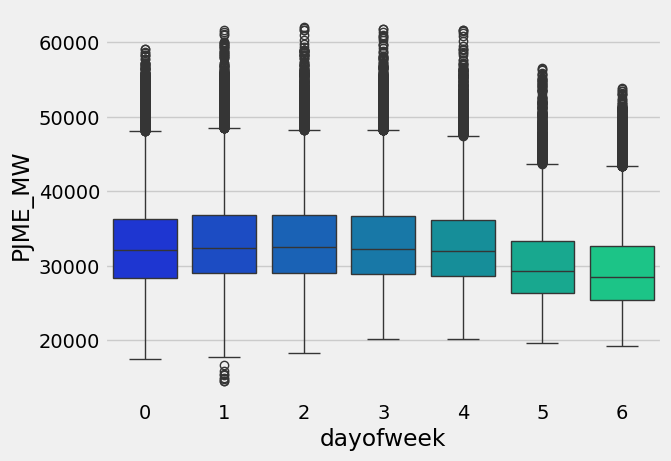

In [121]:
sns.boxplot(data=df, x='dayofweek', y='PJME_MW',palette='winter')
plt.show()

here we can conclude that usally we use in summer season more energy 

### Buildding Model

In [122]:
df = create_features(df)


In [123]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [124]:
import xgboost as xgb
import numpy as np

print("⏳ 1. Nettoyage et conversion absolue en cours...")

try:
    # On force la conversion de TOUTES les variables en tableaux de nombres purs (NumPy)
    X_train_pur = X_train.to_numpy(dtype=float)
    X_test_pur  = X_test.to_numpy(dtype=float)
    y_train_pur = np.ravel(y_train).astype(float)
    y_test_pur  = np.ravel(y_test).astype(float)
    print("✅ Conversion réussie ! Aucune lettre détectée dans les données.")
    
except ValueError as e:
    print("\n❌ ERREUR CRITIQUE DANS LES DONNÉES :")
    print("Ton tableau contient du texte ou des dates ! XGBoost ne lit que des chiffres.")
    print("Détail de l'erreur :", e)
    raise

print("⏳ 2. Lancement de XGBoost...")

# Initialisation du modèle
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)


# Entraînement sur les tableaux purs
reg.fit(
    X_train_pur, 
    y_train_pur,
    eval_set=[(X_train_pur, y_train_pur), (X_test_pur, y_test_pur)],
    verbose=100
)

print("🎉 Entraînement terminé avec succès !")

⏳ 1. Nettoyage et conversion absolue en cours...
✅ Conversion réussie ! Aucune lettre détectée dans les données.
⏳ 2. Lancement de XGBoost...
[0]	validation_0-rmse:32605.13970	validation_1-rmse:31657.15729


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\callback.py:386: UserWarning: [00:42:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12584.35462	validation_1-rmse:11747.28803
[200]	validation_0-rmse:5837.33066	validation_1-rmse:5363.58554
[300]	validation_0-rmse:3923.28511	validation_1-rmse:4020.48045
[400]	validation_0-rmse:3447.54638	validation_1-rmse:3860.60088
[500]	validation_0-rmse:3288.19208	validation_1-rmse:3816.37862
[600]	validation_0-rmse:3206.55619	validation_1-rmse:3779.04119
[700]	validation_0-rmse:3153.61368	validation_1-rmse:3754.45684
[800]	validation_0-rmse:3114.34038	validation_1-rmse:3738.38209
[900]	validation_0-rmse:3084.39550	validation_1-rmse:3730.01893
[989]	validation_0-rmse:3059.85847	validation_1-rmse:3727.94591
🎉 Entraînement terminé avec succès !


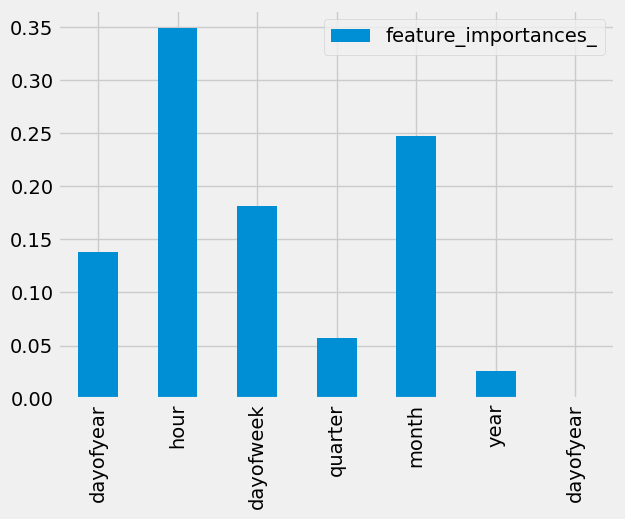

In [125]:
fi =pd.DataFrame(data= reg.feature_importances_, index=X_train.columns, columns=['feature_importances_'])
fi.sort_values(by='feature_importances_', ascending=False)
fi.plot(kind='bar')
plt.show()

### Forcast on test 

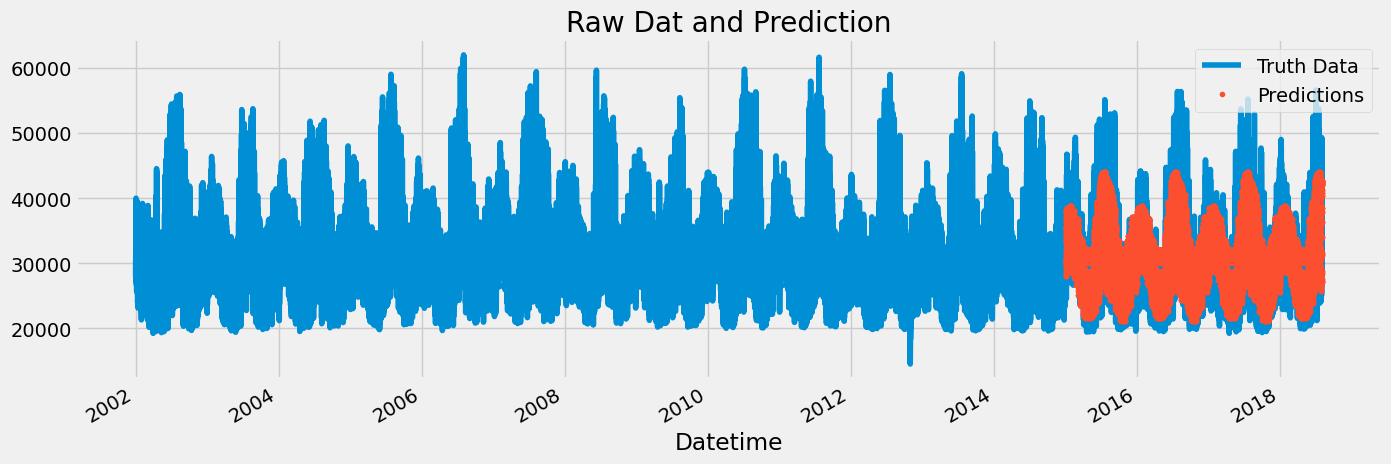

In [127]:
test['prediction']=reg.predict(X_test_pur)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

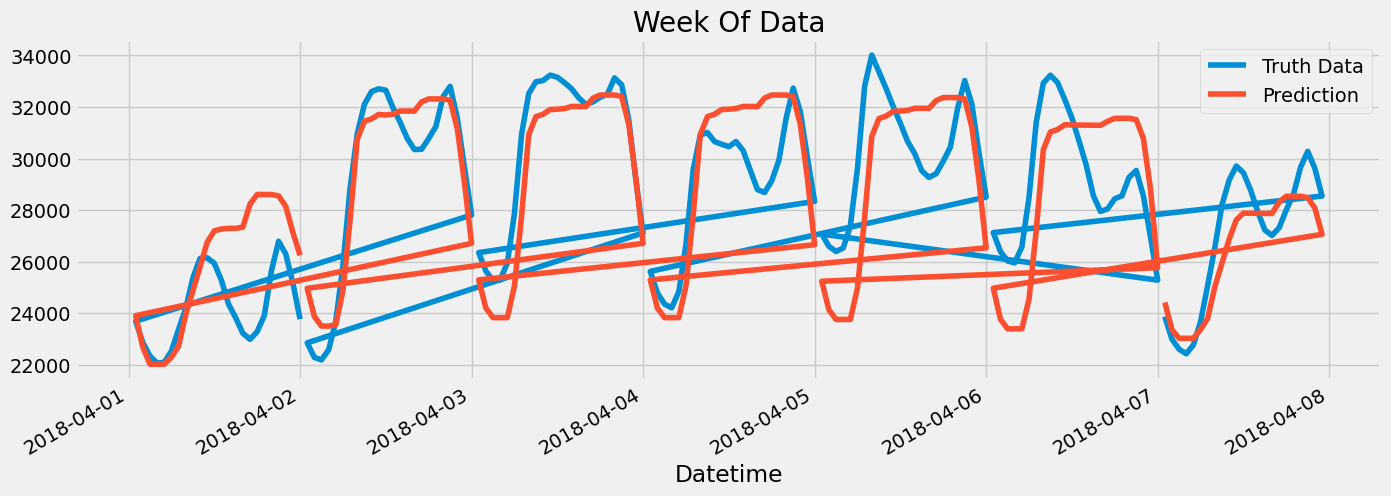

In [129]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['prediction'] \
    .plot(style='-')
plt.legend(['Truth Data','Prediction'])
plt.show()

### MSE

In [133]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')
from sklearn.metrics import r2_score
##3 R2
print(f'R2 Score on Test set: {r2_score(test['PJME_MW'], test['prediction'])}')

RMSE Score on Test set: 3726.80
R2 Score on Test set: 0.6661183856371169
